# 01 · ChArUco 카메라 내부파라미터(Intrinsic) 캘리브레이션

이 프로젝트는 **단일(모노큘러) 카메라 + 크기를 아는 ArUco 마커**로 물체까지의 거리·위치·크기를 구한다.
스테레오 2-카메라 방식(느리고·복잡하고·부정확)을 대체하는 접근이다.

그 첫 단계가 이 노트북: **카메라 내부파라미터(camera matrix `K`, 왜곡계수 `dist`)를 딱 한 번 구한다.**
이 값은 카메라(+해상도)가 바뀌지 않는 한 재사용한다. 이후 모든 `solvePnP` / 거리계산의 기반이 된다.

**전체 파이프라인에서의 위치:**
1. **(이 노트북) ChArUco로 intrinsic `K`, `dist` 산출** ← one-time
2. 씬의 ArUco로 월드좌표계 + 물체 평면 정의
3. 물체 세그멘테이션(고전 CV) → 평면 역투영으로 위치/크기/중심
4. 마커 ID → 물체 메타정보 → 가상 3D 공간 배치

**작업 순서:** ① 아래 셀로 보드 이미지 생성 → 인쇄 → ② 자로 실제 사각형 크기 측정 → ③ 여러 각도로 사진 15~25장 촬영해 `data/calib_images/`에 저장 → ④ 캘리브레이션 실행.

In [1]:
import cv2
import numpy as np
import glob, os
import matplotlib.pyplot as plt

print('OpenCV', cv2.__version__)

# 프로젝트 경로 (notebooks/ 기준 상위가 프로젝트 루트)
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
CALIB_DIR = os.path.join(ROOT, 'data', 'calib_images')
OUTPUT_DIR = os.path.join(ROOT, 'output')
os.makedirs(CALIB_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('ROOT      :', ROOT)
print('CALIB_DIR :', CALIB_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

OpenCV 4.13.0
ROOT      : d:\vision algorithm
CALIB_DIR : d:\vision algorithm\data\calib_images
OUTPUT_DIR: d:\vision algorithm\output


## Step 1 · ChArUco 보드 정의 & 인쇄용 이미지 생성

ChArUco = 체스보드 + ArUco의 결합. 체스보드 코너는 서브픽셀 정밀도가, ArUco는 코너의 고유 ID 식별이 강점이라 둘을 합치면 부분적으로 가려져도 정확히 캘리브레이션된다.

> ⚠️ **가장 중요:** `SQUARE_LENGTH_M`, `MARKER_LENGTH_M`는 **인쇄한 실물을 자로 재서** 미터 단위로 넣어야 한다. 프린터가 배율을 바꾸기 때문에 여기 값이 틀리면 이후 모든 거리가 그 비율만큼 틀어진다. (일단 생성만 하고, 인쇄 후 실측값으로 이 셀을 수정해 다시 실행하면 된다.)

In [2]:
# --- 보드 규격 ---
SQUARES_X = 5          # 가로 사각형 수
SQUARES_Y = 7          # 세로 사각형 수
# 인쇄물 실측: 검은 격자 사각형 한 변 = 38mm.
# 생성 시 비율(22/30)이 고정이라 인쇄해도 유지됨 → 마커 = 38 * 22/30 ≈ 27.9mm.
SQUARE_LENGTH_M = 0.038                    # 격자 사각형 한 변 [m] = 38mm 실측
MARKER_LENGTH_M = 0.038 * 22 / 30          # 내부 마커 한 변 [m] ≈ 0.0279 (27.9mm)
ARUCO_DICT = cv2.aruco.DICT_5X5_1000

dictionary = cv2.aruco.getPredefinedDictionary(ARUCO_DICT)
board = cv2.aruco.CharucoBoard((SQUARES_X, SQUARES_Y), SQUARE_LENGTH_M, MARKER_LENGTH_M, dictionary)
print(f'SQUARE_LENGTH_M={SQUARE_LENGTH_M:.4f}  MARKER_LENGTH_M={MARKER_LENGTH_M:.4f}')

# 참고: 보드 이미지는 이미 output/charuco_board_5x7.png 로 인쇄했으므로 재생성 불필요.
# (다시 만들고 싶으면 아래 주석 해제)
# px_per_square = 200
# board_img = board.generateImage((SQUARES_X*px_per_square, SQUARES_Y*px_per_square), marginSize=40, borderBits=1)
# cv2.imwrite(os.path.join(OUTPUT_DIR, 'charuco_board_5x7.png'), board_img)

SQUARE_LENGTH_M=0.0380  MARKER_LENGTH_M=0.0279


## Step 2 · 캘리브레이션용 사진 촬영

인쇄한 보드를 **평평한 판(하드보드 등)에 완전히 밀착**시키고, **거리(실제 물체 촬영할 때와 비슷한 거리)에서** 각도를 바꿔가며 15~25장 촬영해 `data/calib_images/`에 넣는다.

- 화면 구석·중앙 등 **프레임의 여러 위치**에 보드가 오도록
- 위/아래/좌/우로 **기울여서** (기울기 다양성이 왜곡계수 추정에 중요)
- 초점 맞고 흔들림 없게. **캘리브레이션에 쓴 카메라·해상도·초점 설정을 이후에도 그대로 유지**해야 함.

사진을 넣은 뒤 아래 셀들을 실행.

In [4]:
# calib_images 폴더의 이미지 수집
exts = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG')
image_files = []
for e in exts:
    image_files.extend(glob.glob(os.path.join(CALIB_DIR, e)))
image_files = sorted(set(image_files))
print(f'발견된 캘리브레이션 이미지: {len(image_files)}장')
for f in image_files[:30]:
    print(' ', os.path.basename(f))
assert len(image_files) >= 5, 'calib_images/ 에 최소 5장(권장 15~25장) 이상 넣어주세요.'

발견된 캘리브레이션 이미지: 18장
  WIN_20260705_00_35_37_Pro.jpg
  WIN_20260705_00_35_48_Pro.jpg
  WIN_20260705_00_35_50_Pro.jpg
  WIN_20260705_00_35_52_Pro.jpg
  WIN_20260705_00_35_55_Pro.jpg
  WIN_20260705_00_35_57_Pro.jpg
  WIN_20260705_00_36_01_Pro.jpg
  WIN_20260705_00_36_03_Pro.jpg
  WIN_20260705_00_36_05_Pro.jpg
  WIN_20260705_00_36_08_Pro.jpg
  WIN_20260705_00_36_11_Pro.jpg
  WIN_20260705_00_36_16_Pro.jpg
  WIN_20260705_00_36_19_Pro.jpg
  WIN_20260705_00_36_25_Pro.jpg
  WIN_20260705_00_36_28_Pro.jpg
  WIN_20260705_00_36_31_Pro.jpg
  WIN_20260705_00_36_37_Pro.jpg
  WIN_20260705_00_36_46_Pro.jpg


In [5]:
# ChArUco 코너 검출 (OpenCV 4.7+ 신 API: CharucoDetector)
detector = cv2.aruco.CharucoDetector(board)

all_obj_points = []   # 3D (보드 좌표계)
all_img_points = []   # 2D (이미지 픽셀)
image_size = None     # (width, height)
used, skipped = [], []

for f in image_files:
    img = cv2.imread(f)
    if img is None:
        skipped.append((os.path.basename(f), 'read fail')); continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ch_corners, ch_ids, mk_corners, mk_ids = detector.detectBoard(gray)
    if ch_corners is None or ch_ids is None or len(ch_corners) < 6:
        skipped.append((os.path.basename(f), f'corners={0 if ch_ids is None else len(ch_ids)}')); continue
    # 검출된 charuco 코너 ↔ 보드 3D 점 매칭
    obj_pts, img_pts = board.matchImagePoints(ch_corners, ch_ids)
    if obj_pts is None or len(obj_pts) < 6:
        skipped.append((os.path.basename(f), 'match<6')); continue
    all_obj_points.append(obj_pts)
    all_img_points.append(img_pts)
    image_size = gray.shape[::-1]
    used.append(os.path.basename(f))

print(f'사용: {len(used)}장 / 건너뜀: {len(skipped)}장')
if skipped:
    print('건너뛴 이미지(사유):')
    for name, why in skipped:
        print(f'  - {name}: {why}')
assert len(all_obj_points) >= 5, '유효 검출 이미지가 너무 적습니다. 촬영을 다시 확인하세요.'

사용: 18장 / 건너뜀: 0장


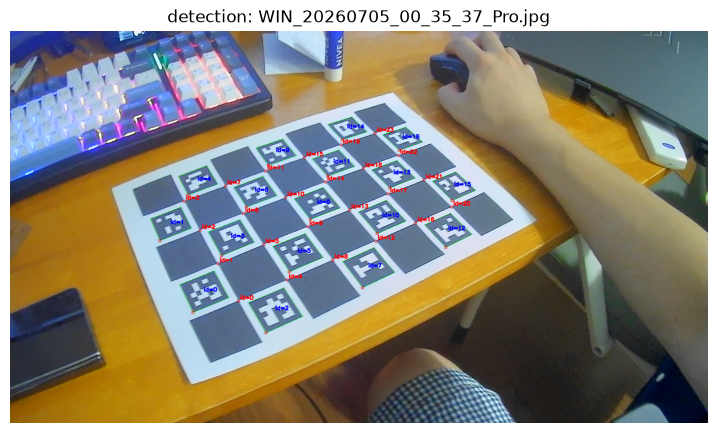

In [6]:
# 검출 시각화 (첫 번째 사용 이미지 확인용)
if used:
    f0 = os.path.join(CALIB_DIR, used[0])
    img = cv2.imread(f0)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ch_corners, ch_ids, mk_corners, mk_ids = detector.detectBoard(gray)
    vis = img.copy()
    if mk_corners:
        cv2.aruco.drawDetectedMarkers(vis, mk_corners, mk_ids)
    if ch_corners is not None:
        cv2.aruco.drawDetectedCornersCharuco(vis, ch_corners, ch_ids, (0, 0, 255))
    plt.figure(figsize=(9, 7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis('off'); plt.title(f'detection: {used[0]}')
    plt.show()

In [7]:
# 캘리브레이션 실행
rms, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    all_obj_points, all_img_points, image_size, None, None
)

print(f'RMS 재투영 오차: {rms:.4f} px  (0.1~1.0px 정도면 양호, >1.5px면 촬영 재검토)')
print('\ncamera_matrix K =\n', camera_matrix)
print('\ndist_coeffs =\n', dist_coeffs.ravel())
print('\nimage_size (w,h) =', image_size)
fx, fy = camera_matrix[0, 0], camera_matrix[1, 1]
cx, cy = camera_matrix[0, 2], camera_matrix[1, 2]
print(f'\nfx={fx:.1f}  fy={fy:.1f}  cx={cx:.1f}  cy={cy:.1f}')

RMS 재투영 오차: 0.6131 px  (0.1~1.0px 정도면 양호, >1.5px면 촬영 재검토)

camera_matrix K =
 [[1.42870114e+03 0.00000000e+00 8.97987651e+02]
 [0.00000000e+00 1.45112605e+03 5.76865072e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

dist_coeffs =
 [-3.59477496e-01  8.88905243e-02 -1.21840285e-02  1.48078717e-04
  3.54635490e-02]

image_size (w,h) = (1920, 1080)

fx=1428.7  fy=1451.1  cx=898.0  cy=576.9


In [8]:
# per-image 재투영 오차 (이상치 이미지 찾기)
errors = []
for i in range(len(all_obj_points)):
    proj, _ = cv2.projectPoints(all_obj_points[i], rvecs[i], tvecs[i], camera_matrix, dist_coeffs)
    err = cv2.norm(all_img_points[i], proj, cv2.NORM_L2) / len(proj)
    errors.append(err)

order = np.argsort(errors)[::-1]
print('재투영 오차 큰 순 (px):')
for i in order[:min(10, len(order))]:
    print(f'  {used[i]:30s} {errors[i]:.4f}')
print(f'\n평균 {np.mean(errors):.4f}px  최대 {np.max(errors):.4f}px')
print('→ 특정 이미지만 오차가 크면 그 사진을 빼고 재실행하면 개선될 수 있음.')

재투영 오차 큰 순 (px):
  WIN_20260705_00_36_08_Pro.jpg  0.4230
  WIN_20260705_00_36_16_Pro.jpg  0.1829
  WIN_20260705_00_36_11_Pro.jpg  0.1740
  WIN_20260705_00_35_52_Pro.jpg  0.1621
  WIN_20260705_00_36_37_Pro.jpg  0.1574
  WIN_20260705_00_35_48_Pro.jpg  0.1249
  WIN_20260705_00_36_03_Pro.jpg  0.1215
  WIN_20260705_00_36_19_Pro.jpg  0.1184
  WIN_20260705_00_36_05_Pro.jpg  0.1145
  WIN_20260705_00_35_55_Pro.jpg  0.1094

평균 0.1366px  최대 0.4230px
→ 특정 이미지만 오차가 크면 그 사진을 빼고 재실행하면 개선될 수 있음.


In [9]:
# 결과 저장 (이후 노트북에서 재사용)
intrinsics_path = os.path.join(OUTPUT_DIR, 'camera_intrinsics.npz')
np.savez(
    intrinsics_path,
    camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs,
    image_size=np.array(image_size),
    rms=rms,
    square_length_m=SQUARE_LENGTH_M,
    marker_length_m=MARKER_LENGTH_M,
)
print('저장 완료:', intrinsics_path)

# 사람이 읽기 좋은 형식으로도 저장 (OpenCV FileStorage YAML)
yaml_path = os.path.join(OUTPUT_DIR, 'camera_intrinsics.yaml')
fs = cv2.FileStorage(yaml_path, cv2.FILE_STORAGE_WRITE)
fs.write('camera_matrix', camera_matrix)
fs.write('dist_coeffs', dist_coeffs)
fs.write('image_width', int(image_size[0]))
fs.write('image_height', int(image_size[1]))
fs.write('rms', float(rms))
fs.release()
print('저장 완료:', yaml_path)

저장 완료: d:\vision algorithm\output\camera_intrinsics.npz
저장 완료: d:\vision algorithm\output\camera_intrinsics.yaml


## 다음 단계

`output/camera_intrinsics.npz`가 생기면 intrinsic 캘리브레이션 완료. 다음 노트북(`02_pose_estimation.ipynb`)에서:
- 씬 사진에서 ArUco 검출 → `solvePnP`로 각 마커의 6-DoF 포즈(카메라→마커) 산출
- 한 마커를 원점으로 하는 **월드좌표계** 정의, 마커들이 놓인 **평면** 추정
- 카메라→물체 거리 계산의 기반 마련

그 다음 `03_object_localize.ipynb`에서 물체 세그멘테이션 + 평면 역투영으로 위치/크기/중심을 구한다.